# UMAP

In [1]:
import pandas as pd
import numpy as np
from umap import UMAP
import matplotlib.pyplot as plt
import seaborn as sns
import os

# =====================================================
# 0) FOLDER OUTPUT
# =====================================================
output_dir = r"C:\Fauzan\Manuskrip QSAR 3\Revisi 1\UMAP"
os.makedirs(output_dir, exist_ok=True)

# =====================================================
# 1) KONFIGURASI ENDPOINT + LABEL KONSISTEN
# =====================================================
endpoints = [
    {
        "endpoint": "Drug Induced Nephrotoxicity",
        "file_tag": "Drug_Induced_Nephrotoxicity",
        "datasets": [
            {
                "label": "Drug Induced Nephrotoxicity – Train Set",
                "file": r"C:\Fauzan\Manuscripts QSAR-RA 2\Manuscript\AD Analysis\Drug Induced Nephrotoxicity\Train_Set_with_fingerprints_sorted_with_RDKit_and_CDK_features.xlsx"
            },
            {
                "label": "Drug Induced Nephrotoxicity – External Validation",
                "file": r"C:\Fauzan\Manuscripts QSAR-RA 2\Manuscript\AD Analysis\Drug Induced Nephrotoxicity\External Validation_with_fingerprints_sorted_with_RDKit_and_CDK_features.xlsx"
            },
            {
                "label": "Drug Induced Nephrotoxicity – Unseen Test Set",
                "file": r"C:\Fauzan\Manuscripts QSAR-RA 2\Manuscript\AD Analysis\Drug Induced Nephrotoxicity\Test_Set_with_fingerprints_sorted_with_RDKit_and_CDK_features.xlsx"
            },
        ]
    },
    {
        "endpoint": "AMES Mutagenicity",
        "file_tag": "AMES_Mutagenicity",
        "datasets": [
            {
                "label": "AMES Mutagenicity – Train Set",
                "file": r"C:\Fauzan\Manuscripts QSAR-RA 2\Manuscript\AD Analysis\AMES\AMES_Train set.xlsx"
            },
            {
                "label": "AMES Mutagenicity – External Validation 1",
                "file": r"C:\Fauzan\Manuscripts QSAR-RA 2\Manuscript\AD Analysis\AMES\AMES_Set1_external_validation.xlsx"
            },
            {
                "label": "AMES Mutagenicity – External Validation 2",
                "file": r"C:\Fauzan\Manuscripts QSAR-RA 2\Manuscript\AD Analysis\AMES\AMES_Set2_external_validation.xlsx"
            },
        ]
    },
    {
        "endpoint": "Developmental Toxicity",
        "file_tag": "Developmental_Toxicity",
        "datasets": [
            {
                "label": "Developmental Toxicity – Train Set",
                "file": r"C:\Fauzan\Manuscripts QSAR-RA 2\Manuscript\AD Analysis\Development Toxicity\Dev_Train set_with_fingerprints_sorted_with_RDKit_and_CDK_features.xlsx"
            },
            {
                "label": "Developmental Toxicity – Unseen Test Set",
                "file": r"C:\Fauzan\Manuscripts QSAR-RA 2\Manuscript\AD Analysis\Development Toxicity\Dev_Test_set_balanced_with_fingerprints_sorted_with_RDKit_and_CDK_features.xlsx"
            },
        ]
    },
    {
        "endpoint": "Hepatotoxicity",
        "file_tag": "Hepatotoxicity",
        "datasets": [
            {
                "label": "Hepatotoxicity – Train Set",
                "file": r"C:\Fauzan\Manuscripts QSAR-RA 2\Manuscript\AD Analysis\Hepatoxicity\HEP_Train_set_train_with_fingerprints_sorted_with_RDKit_and_CDK_features.xlsx"
            },
            {
                "label": "Hepatotoxicity – External Validation 1",
                "file": r"C:\Fauzan\Manuscripts QSAR-RA 2\Manuscript\AD Analysis\Hepatoxicity\Test_set_ValRandom_fingerprints_with_RDKit_CDK.xlsx"
            },
            {
                "label": "Hepatotoxicity – External Validation 2",
                "file": r"C:\Fauzan\Manuscripts QSAR-RA 2\Manuscript\AD Analysis\Hepatoxicity\Ext_Val_ValBLACK_blackNE_.xlsx"
            },
        ]
    },
    {
        "endpoint": "Neurotoxicity",
        "file_tag": "Neurotoxicity",
        "datasets": [
            {
                "label": "Neurotoxicity – Train Set",
                "file": r"C:\Fauzan\Manuscripts QSAR-RA 2\Manuscript\AD Analysis\NeuroToxicity\Train_Set_with_fingerprints_with_RDKit_and_CDK_features.xlsx"
            },
            {
                "label": "Neurotoxicity – Unseen Test Set",
                "file": r"C:\Fauzan\Manuscripts QSAR-RA 2\Manuscript\AD Analysis\NeuroToxicity\Validation_Set_with_fingerprints_with_RDKit_and_CDK_features.xlsx"
            },
        ]
    },
    {
        "endpoint": "Respiratory Toxicity",
        "file_tag": "Respiratory_Toxicity",
        "datasets": [
            {
                "label": "Respiratory Toxicity – Train Set",
                "file": r"C:\Fauzan\Manuscripts QSAR-RA 2\Manuscript\AD Analysis\Respiratory Tox\Resp_Train_set_with_fingerprints_sorted_with_RDKit_and_CDK_features.xlsx"
            },
            {
                "label": "Respiratory Toxicity – Unseen Test Set",
                "file": r"C:\Fauzan\Manuscripts QSAR-RA 2\Manuscript\AD Analysis\Respiratory Tox\Resp_Test_set_with_fingerprints_sorted_with_RDKit_and_CDK_features.xlsx"
            },
            {
                "label": "Respiratory Toxicity – External Validation",
                "file": r"C:\Fauzan\Manuscripts QSAR-RA 2\Manuscript\AD Analysis\Respiratory Tox\Resp_External_validation_with_fingerprints_sorted_with_RDKit_and_CDK_features.xlsx"
            },
        ]
    },
    {
        "endpoint": "Skin Sensitization",
        "file_tag": "Skin_Sensitization",
        "datasets": [
            {
                "label": "Skin Sensitization – Train Set",
                "file": r"C:\Fauzan\Manuscripts QSAR-RA 2\Manuscript\AD Analysis\Skin Sensinization\SkinSen_Train_set_with_fingerprints_sorted_with_RDKit_and_CDK_features.xlsx"
            },
            {
                "label": "Skin Sensitization – Unseen Test Set",
                "file": r"C:\Fauzan\Manuscripts QSAR-RA 2\Manuscript\AD Analysis\Skin Sensinization\SkinSen_Test_set_with_fingerprints_sorted_with_RDKit_and_CDK_features.xlsx"
            },
        ]
    },
    {
        "endpoint": "Cardiotoxicity",
        "file_tag": "Cardiotoxicity",
        "datasets": [
            {
                "label": "Cardiotoxicity – Train Set",
                "file": r"C:\Fauzan\Manuscripts QSAR-RA 2\Manuscript\AD Analysis\Cardiotoxicity\CardioTox_Train_set_with_fingerprints_sorted_with_RDKit_and_CDK_features.xlsx"
            },
            {
                "label": "Cardiotoxicity – External Validation 1",
                "file": r"C:\Fauzan\Manuscripts QSAR-RA 2\Manuscript\AD Analysis\Cardiotoxicity\CardioTox_Test_set 1_with_fingerprints_sorted_with_RDKit_and_CDK_features.xlsx"
            },
            {
                "label": "Cardiotoxicity – External Validation 2",
                "file": r"C:\Fauzan\Manuscripts QSAR-RA 2\Manuscript\AD Analysis\Cardiotoxicity\CardioTox_Test_set 2_with_fingerprints_sorted_with_RDKit_and_CDK_features.xlsx"
            },
            {
                "label": "Cardiotoxicity – External Validation 3",
                "file": r"C:\Fauzan\Manuscripts QSAR-RA 2\Manuscript\AD Analysis\Cardiotoxicity\CardioTox_Test_set 3_with_fingerprints_sorted_with_RDKit_and_CDK_features.xlsx"
            },
        ]
    },
]

# =====================================================
# 2) FUNGSI KONVERSI MORGAN
# =====================================================
def morgan_to_array(desc):
    if pd.isna(desc):
        return np.array([])
    if isinstance(desc, str):
        desc_clean = (
            desc.replace('[', '')
                .replace(']', '')
                .replace('\n', '')
                .strip()
        )
        if desc_clean == '':
            return np.array([])
        return np.array([int(x) for x in desc_clean.split(',')])
    elif isinstance(desc, (list, np.ndarray)):
        return np.array(desc)
    else:
        return np.array([])

# =====================================================
# 3) PARAMETER STYLE GLOBAL TANPA GRID
# =====================================================
sns.set_style("white")   # tidak ada grid / kotak-kotak [web:49][web:18]
FIG_SIZE = (8, 6)

# =====================================================
# 4) LOOP: 1 PLOT / ENDPOINT
# =====================================================
for ep in endpoints:
    endpoint_name = ep["endpoint"]
    file_tag = ep["file_tag"]
    print(f"Processing endpoint: {endpoint_name}")

    all_fps = []
    labels = []

    for ds in ep["datasets"]:
        df = pd.read_excel(ds["file"])
        df["Morgan_FP"] = df["Morgan_Descriptors"].apply(morgan_to_array)
        fps = [fp for fp in df["Morgan_FP"] if len(fp) > 0]
        all_fps.extend(fps)
        labels.extend([ds["label"]] * len(fps))

    if len(all_fps) == 0:
        print(f"WARNING: no valid fingerprints for {endpoint_name}, skipped.")
        continue

    all_fps = np.array(all_fps)

    # UMAP
    umap_model = UMAP(n_components=2, random_state=42)
    umap_results = umap_model.fit_transform(all_fps)

    # PLOT (tanpa grid)
    plt.figure(figsize=FIG_SIZE)
    ax = sns.scatterplot(
        x=umap_results[:, 0],
        y=umap_results[:, 1],
        hue=labels,
        palette="Set1",
        s=50,
        alpha=0.7
    )

    # pastikan tidak ada grid di axes (jaga-jaga)
    ax.grid(False)  # mematikan grid di matplotlib axes [web:53][web:61]

    plt.title(f"UMAP Chemical Space – {endpoint_name}")
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.legend(title="Datasets")
    plt.tight_layout()

    out_path = os.path.join(output_dir, f"UMAP_{file_tag}.png")
    plt.savefig(out_path, dpi=300)
    plt.close()
    print(f"Saved: {out_path}")


Processing endpoint: Drug Induced Nephrotoxicity


C:\Users\USER-PC\anaconda3\envs\my-work-env\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Saved: C:\Fauzan\Manuskrip QSAR 3\Revisi 1\UMAP\UMAP_Drug_Induced_Nephrotoxicity.png
Processing endpoint: AMES Mutagenicity


C:\Users\USER-PC\anaconda3\envs\my-work-env\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\USER-PC\anaconda3\envs\my-work-env\lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
C:\Users\USER-PC\anaconda3\envs\my-work-env\lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


Saved: C:\Fauzan\Manuskrip QSAR 3\Revisi 1\UMAP\UMAP_AMES_Mutagenicity.png
Processing endpoint: Developmental Toxicity


...

Saved: C:\Fauzan\Manuskrip QSAR 3\Revisi 1\UMAP\UMAP_Respiratory_Toxicity.png
Processing endpoint: Skin Sensitization


C:\Users\USER-PC\anaconda3\envs\my-work-env\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Saved: C:\Fauzan\Manuskrip QSAR 3\Revisi 1\UMAP\UMAP_Skin_Sensitization.png
Processing endpoint: Cardiotoxicity


C:\Users\USER-PC\anaconda3\envs\my-work-env\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\USER-PC\anaconda3\envs\my-work-env\lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
C:\Users\USER-PC\anaconda3\envs\my-work-env\lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


Saved: C:\Fauzan\Manuskrip QSAR 3\Revisi 1\UMAP\UMAP_Cardiotoxicity.png


# AD Anaylysis

In [ ]:
import os
import pandas as pd
import numpy as np
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem, MACCSkeys, rdMolDescriptors
import matplotlib.pyplot as plt
import ast

# ===============================
# Fungsi konversi list → ExplicitBitVect aman
# ===============================
def convert_to_bitvect(fp_list, n_bits=None):
    if isinstance(fp_list, str):
        try:
            fp_list = ast.literal_eval(fp_list)
        except:
            fp_list = []
    if fp_list is None or len(fp_list) == 0:
        if n_bits is None:
            raise ValueError("n_bits harus ditentukan jika fingerprint kosong")
        fp_list = [0]*n_bits
    if n_bits is None:
        n_bits = len(fp_list)
    bv = DataStructs.ExplicitBitVect(n_bits)
    for i, bit in enumerate(fp_list):
        if bit:
            bv.SetBit(i)
    return bv

# ===============================
# Max Tanimoto similarity function cepat
# ===============================
def max_similarity_to_train_fast(fp_test_list, fp_train_list):
    max_sims = []
    train_bvs = [convert_to_bitvect(fp) for fp in fp_train_list]
    n_bits_list = len(train_bvs[0])
    for fp_test in fp_test_list:
        test_bv = convert_to_bitvect(fp_test, n_bits=n_bits_list)
        sims = DataStructs.BulkTanimotoSimilarity(test_bv, train_bvs)
        max_sims.append(max(sims))
    return np.array(max_sims)

# ===============================
# Leverage physicochemical
# ===============================
def leverage_physchem(X_train, X_test):
    X_train = np.array(X_train)
    X_test = np.array(X_test)
    n_samples, n_features = X_train.shape
    X_train_aug = np.hstack([np.ones((n_samples,1)), X_train])
    X_test_aug = np.hstack([np.ones((X_test.shape[0],1)), X_test])
    XtX_inv = np.linalg.pinv(X_train_aug.T @ X_train_aug)
    H_test = np.sum((X_test_aug @ XtX_inv) * X_test_aug, axis=1)
    h_star = 3*(n_features+1)/n_samples
    return H_test, h_star, H_test <= h_star

# ===============================
# Input files Carcinogenicity
# ===============================
input_files = [
    r"C:\Fauzan\Manuskrip QSAR 3\Hepatotoxicity\HEP_Train_set_train_with_fingerprints_RDKit_CDK.xlsx",  # train set
    r"C:\Fauzan\Manuskrip QSAR 3\Hepatotoxicity\ValBLACK_blackNE_outcome_with_fingerprints_RDKit_CDK.xlsx",
    r"C:\Fauzan\Manuskrip QSAR 3\Hepatotoxicity\ValRandom_with_fingerprints_RDKit_CDK.xlsx"
]

# ===============================
# Baca Train set
# ===============================
train_df = pd.read_excel(input_files[0])

# Kolom physicochemical (sesuaikan jika berbeda)
physchem_cols = [col for col in train_df.columns if col not in 
                 ["SMILES","Outcome","Morgan_Descriptors","MACCS_Descriptors","APF_Descriptors"]]

# ===============================
# Loop setiap file
# ===============================
for file_path in input_files:
    print(f"Processing: {file_path}")
    df = pd.read_excel(file_path)
    
    # ===============================
    # Fingerprints
    # ===============================
    tanimoto_scores = {}
    for fp_name in ["Morgan_Descriptors","MACCS_Descriptors","APF_Descriptors"]:
        train_fps = train_df[fp_name].tolist()
        test_fps = df[fp_name].tolist()
        max_sims = max_similarity_to_train_fast(test_fps, train_fps)
        df[f"{fp_name}_IN_AD"] = max_sims >= 0.5
        tanimoto_scores[fp_name] = max_sims
    
    # ===============================
    # Physicochemical
    # ===============================
    X_train = train_df[physchem_cols].values
    X_test = df[physchem_cols].values
    H_test, h_star, physchem_in_ad = leverage_physchem(X_train, X_test)
    df["Physchem_IN_AD"] = physchem_in_ad
    
    # ===============================
    # Consensus ≥2 dari 4 descriptor
    # ===============================
    df["Consensus_IN_AD"] = df[["Morgan_Descriptors_IN_AD","MACCS_Descriptors_IN_AD",
                                "APF_Descriptors_IN_AD","Physchem_IN_AD"]].sum(axis=1) >= 2
    
    # ===============================
    # Summary
    # ===============================
    summary = {
        "Total compounds": len(df),
        "% Morgan IN AD": df["Morgan_Descriptors_IN_AD"].mean()*100,
        "% MACCS IN AD": df["MACCS_Descriptors_IN_AD"].mean()*100,
        "% APF IN AD": df["APF_Descriptors_IN_AD"].mean()*100,
        "% Physchem IN AD": df["Physchem_IN_AD"].mean()*100,
        "% Consensus IN AD": df["Consensus_IN_AD"].mean()*100
    }
    print(pd.Series(summary))
    
    # ===============================
    # Visualisasi AD coverage
    # ===============================
    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    plt.bar(summary.keys(), summary.values(), color=['skyblue','orange','green','red','purple'])
    plt.ylabel('Percentage (%)')
    plt.ylim(0,100)
    plt.xticks(rotation=45)
    plt.title(f"AD Coverage (Bar) - {os.path.basename(file_path)}")

    plt.subplot(1,2,2)
    # Boxplot Tanimoto + leverage
    data_box = [tanimoto_scores.get("Morgan_Descriptors",[]),
                tanimoto_scores.get("MACCS_Descriptors",[]),
                tanimoto_scores.get("APF_Descriptors",[]),
                H_test]
    plt.boxplot(data_box, labels=["Morgan","MACCS","APF","Physchem"])
    plt.ylabel("Score / Leverage")
    plt.title("Distribution of AD Scores")
    plt.tight_layout()
    plt.show()
    
    # ===============================
    # Simpan hasil Excel
    # ===============================
    output_path = file_path.replace(".xlsx","_AD_results.xlsx")
    df.to_excel(output_path, index=False)
    print(f"Saved Excel: {output_path}\n")

print("✅ All files processed!")


# Visualization (AD)

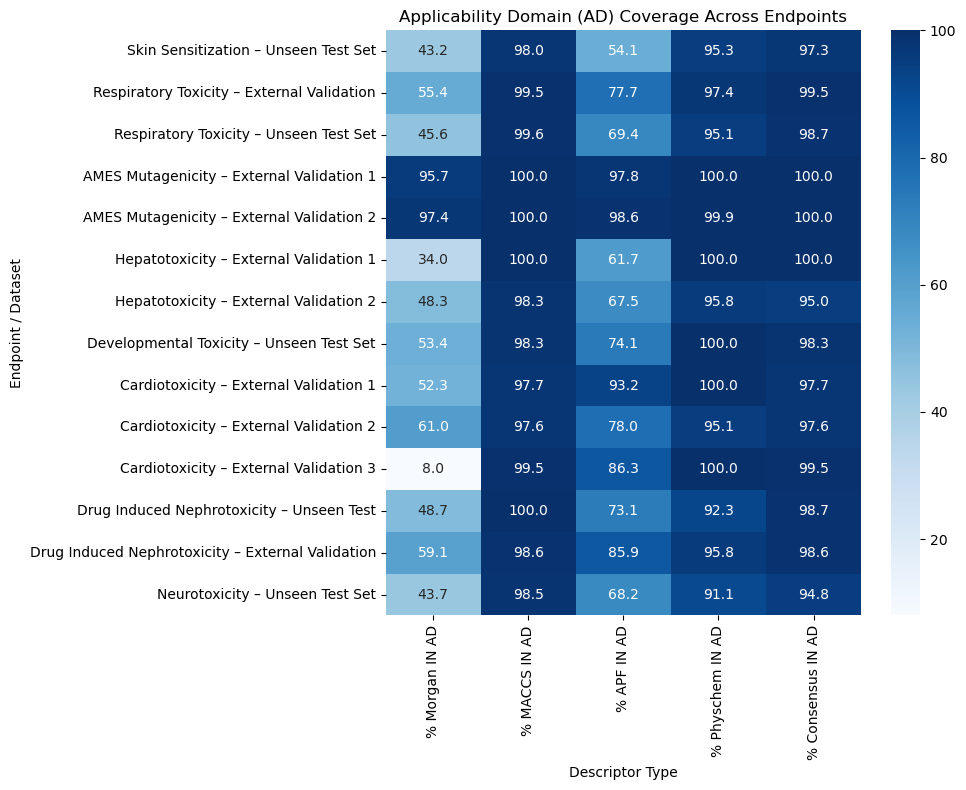

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = {
    "Endpoint / Dataset": [
        "Skin Sensitization – Unseen Test Set",
        "Respiratory Toxicity – External Validation",
        "Respiratory Toxicity – Unseen Test Set",
        "AMES Mutagenicity – External Validation 1",
        "AMES Mutagenicity – External Validation 2",
        "Hepatotoxicity – External Validation 1",
        "Hepatotoxicity – External Validation 2",
        "Developmental Toxicity – Unseen Test Set",
        "Cardiotoxicity – External Validation 1",
        "Cardiotoxicity – External Validation 2",
        "Cardiotoxicity – External Validation 3",
        "Drug Induced Nephrotoxicity – Unseen Test",
        "Drug Induced Nephrotoxicity – External Validation",
        "Neurotoxicity – Unseen Test Set",
    ],
    "% Morgan IN AD": [43.2, 55.4, 45.6, 95.7, 97.4, 34.0, 48.3, 53.4, 52.3, 61.0, 8.0, 48.7, 59.1, 43.7],
    "% MACCS IN AD":  [98.0, 99.5, 99.6, 100.0, 100.0, 100.0, 98.3, 98.3, 97.7, 97.6, 99.5, 100.0, 98.6, 98.5],
    "% APF IN AD":    [54.1, 77.7, 69.4, 97.8, 98.6, 61.7, 67.5, 74.1, 93.2, 78.0, 86.3, 73.1, 85.9, 68.2],
    "% Physchem IN AD": [95.3, 97.4, 95.1, 100.0, 99.9, 100.0, 95.8, 100.0, 100.0, 95.1, 100.0, 92.3, 95.8, 91.1],
    "% Consensus IN AD": [97.3, 99.5, 98.7, 100.0, 100.0, 100.0, 95.0, 98.3, 97.7, 97.6, 99.5, 98.7, 98.6, 94.8],
}

df = pd.DataFrame(data)

plt.figure(figsize=(10, 8))
heatmap_data = df.set_index("Endpoint / Dataset")
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="Blues")
plt.title("Applicability Domain (AD) Coverage Across Endpoints")
plt.xlabel("Descriptor Type")
plt.ylabel("Endpoint / Dataset")
plt.tight_layout()
plt.show()
